In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# Carga desde archivos locales
df_day  = pd.read_csv('Cvs/day.csv')
df_hour = pd.read_csv('Cvs/hour.csv')
print(f'day.csv:  {df_day.shape}  |  hour.csv: {df_hour.shape}')

day.csv:  (731, 16)  |  hour.csv: (17379, 17)


In [6]:
# Anulacion: indice, fecha redundante y data leakage
# casual + registered = cnt -> se eliminan para evitar leakage
cols_drop = ['instant', 'dteday', 'casual', 'registered']
df_day  = df_day.drop(columns=cols_drop)
df_hour = df_hour.drop(columns=cols_drop)

# Eliminar columnas con varianza = 0
for df, nombre in [(df_day,'day'), (df_hour,'hour')]:
    sigma  = df.std(numeric_only=True)
    planas = sigma[sigma == 0].index.tolist()
    if planas:
        df.drop(columns=planas, inplace=True)
    print(f'{nombre}: {df.shape}  |  varianza=0: {planas or "ninguna"}')

day: (731, 12)  |  varianza=0: ninguna
hour: (17379, 13)  |  varianza=0: ninguna


In [7]:
# Limpieza: verificar nulos y duplicados
print(f'Nulos  day: {df_day.isnull().sum().sum()}  |  hour: {df_hour.isnull().sum().sum()}')
print(f'Dupes  day: {df_day.duplicated().sum()}     |  hour: {df_hour.duplicated().sum()}')

Nulos  day: 0  |  hour: 0
Dupes  day: 0     |  hour: 2


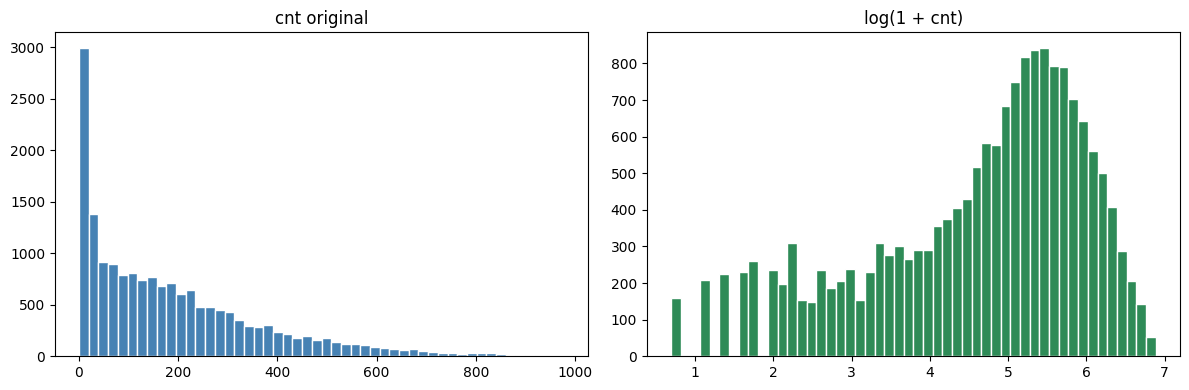

media: 189.5  mediana: 142.0


In [8]:
# Distribucion del target y balanceo
# cnt tiene sesgo derecho -> log(1+cnt) lo suaviza
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_hour['cnt'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('cnt original')
axes[1].hist(np.log1p(df_hour['cnt']), bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('log(1 + cnt)')
plt.tight_layout()
plt.show()

print(f'media: {df_hour["cnt"].mean():.1f}  mediana: {df_hour["cnt"].median():.1f}')

In [9]:
# Preparacion con hour.csv
df = df_hour.copy()

TARGET = 'cnt'
X = df.drop(columns=[TARGET])
y = np.log1p(df[TARGET].values)   # log-transform para balanceo del sesgo

# One-Hot Encoding de categoricas
X = pd.get_dummies(X, columns=['season','weathersit','mnth','weekday','hr'], drop_first=False)
X = X.values.astype(np.float32)

# Split temporal (serie de tiempo -> no aleatorio)
n       = len(X)
n_train = int(n * 0.80)
n_val   = int(n * 0.10)

X_train, y_train = X[:n_train],             y[:n_train]
X_val,   y_val   = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test,  y_test  = X[n_train+n_val:],        y[n_train+n_val:]

# Normalizacion manual (fit solo en train)
mu, sigma    = X_train.mean(axis=0), X_train.std(axis=0)
sigma[sigma == 0] = 1
X_train = (X_train - mu) / sigma
X_val   = (X_val   - mu) / sigma
X_test  = (X_test  - mu) / sigma

# Normalizar y a [0,1]
y_min, y_max = y_train.min(), y_train.max()
y_train = ((y_train - y_min) / (y_max - y_min)).astype(np.float32)
y_val   = ((y_val   - y_min) / (y_max - y_min)).astype(np.float32)
y_test  = ((y_test  - y_min) / (y_max - y_min)).astype(np.float32)

print(f'Input size: {X_train.shape[1]}')
print(f'Train: {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}')

Input size: 58
Train: (13903, 58)  |  Val: (1737, 58)  |  Test: (1739, 58)


In [10]:
np.save('bike_X_train.npy', X_train);  np.save('bike_y_train.npy', y_train)
np.save('bike_X_val.npy',   X_val);    np.save('bike_y_val.npy',   y_val)
np.save('bike_X_test.npy',  X_test);   np.save('bike_y_test.npy',  y_test)
np.save('bike_params.npy', np.array([y_min, y_max]))
print('Guardado. Input size:', X_train.shape[1])

Guardado. Input size: 58


In [11]:
# Carga rapida en otro notebook
X_train = np.load('bike_X_train.npy');  y_train = np.load('bike_y_train.npy')
X_val   = np.load('bike_X_val.npy');    y_val   = np.load('bike_y_val.npy')
X_test  = np.load('bike_X_test.npy');   y_test  = np.load('bike_y_test.npy')
y_min, y_max = np.load('bike_params.npy')

INPUT_SIZE = X_train.shape[1]
print(f'Input size: {INPUT_SIZE}')
# Para invertir: np.expm1(y_pred * (y_max - y_min) + y_min)

Input size: 58
